**Name-Ujjawal chauhan 
roll no-62 'B'
cu24250259
Labsheet=08**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
video_path = "5009674-hd_1920_1080_25fps.mp4"

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Video not found!")
else:
    print("Video loaded successfully!")

Video loaded successfully!


In [3]:
ret, old_frame = cap.read()

if not ret:
    print("Error: Could not read video!")
else:
    print("First frame read successfully!")

print("Frame size:", old_frame.shape)

First frame read successfully!
Frame size: (1080, 1920, 3)


In [4]:
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

print("Frame converted to grayscale!")

Frame converted to grayscale!


In [5]:
feature_params = dict(
    maxCorners=100,
    qualityLevel=0.3,
    minDistance=7,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(
    old_gray,
    mask=None,
    **feature_params
)

print("Number of feature points detected:", len(p0))

Number of feature points detected: 100


In [6]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS |
        cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)

print("Lucas-Kanade parameters set!")

Lucas-Kanade parameters set!


In [8]:
mask = np.zeros_like(old_frame)

print("Tracking mask created!")

Tracking mask created!


In [9]:
ret, frame = cap.read()

if ret:

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    p1, st, err = cv2.calcOpticalFlowPyrLK(
        old_gray,
        frame_gray,
        p0,
        None,
        **lk_params
    )

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    output = frame.copy()

    for new, old in zip(good_new, good_old):

        x_new, y_new = new.ravel()
        x_old, y_old = old.ravel()

        x_new = int(x_new)
        y_new = int(y_new)
        x_old = int(x_old)
        y_old = int(y_old)

        # Draw trajectory
        mask = cv2.line(
            mask,
            (x_new, y_new),
            (x_old, y_old),
            (255, 255, 255),
            2
        )

        # Draw feature point
        output = cv2.circle(
            output,
            (x_new, y_new),
            5,
            (255, 255, 255),
            -1
        )

    output = cv2.add(output, mask)

    print("Lucas-Kanade tracking completed!")

else:
    print("Could not read frame!")

Lucas-Kanade tracking completed!


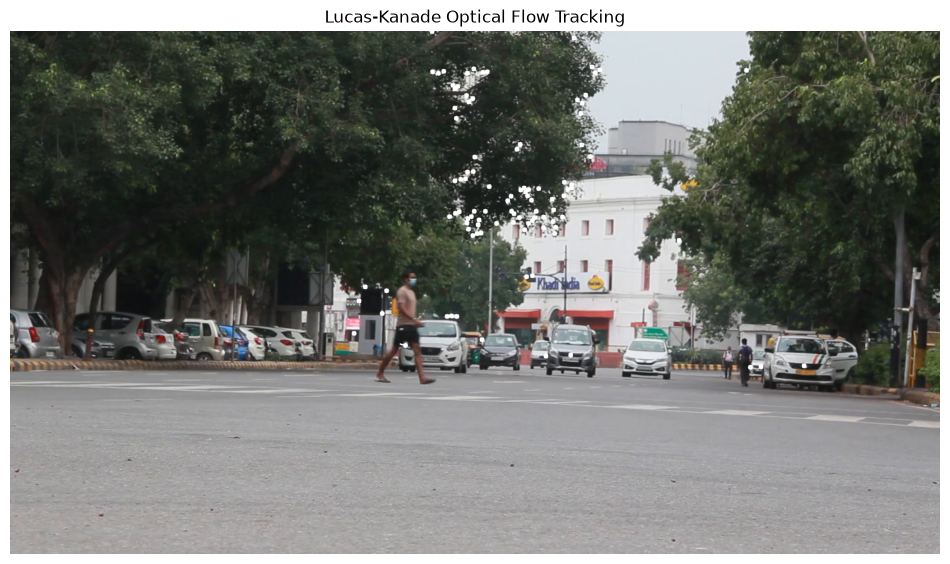

In [10]:
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(output_rgb)
plt.title("Lucas-Kanade Optical Flow Tracking")
plt.axis("off")
plt.show()

In [11]:
displacements = []

for new, old in zip(good_new, good_old):

    dx = new[0] - old[0]
    dy = new[1] - old[1]

    distance = np.sqrt(dx**2 + dy**2)

    displacements.append(distance)

if len(displacements) > 0:
    average_displacement = np.mean(displacements)

    print("Average displacement:",
          round(average_displacement, 2),
          "pixels")
else:
    print("No displacement calculated.")

Average displacement: 0.29 pixels
